In [38]:
import numpy as np
import mlflow
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt


In [ ]:
import numpy as np
import mlflow
from sklearn.model_selection import KFold

class LinearRegression(object):

    kfold = KFold(n_splits=3, shuffle=True, random_state=42)

    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500,
                 batch_size=50, cv=kfold, init_method='zeros',
                 use_momentum=False, momentum=0.9, max_grad_norm=5.0,
                 patience=10, shuffle=True):
        self.lr             = lr
        self.num_epochs     = num_epochs
        self.batch_size     = batch_size
        self.method         = method
        self.cv             = cv
        self.regularization = regularization

        self.init_method    = init_method
        self.use_momentum   = use_momentum
        self.momentum       = momentum
        self.max_grad_norm  = max_grad_norm
        self.patience       = patience
        self.shuffle        = shuffle

    def mse(self, ytrue, ypred):
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]

    def r2(self, ytrue, ypred):
        ss_res = ((ypred - ytrue) ** 2).sum()
        ss_tot = ((ytrue - ytrue.mean()) ** 2).sum()
        if ss_tot == 0:
            return 0.0
        return 1 - (ss_res / ss_tot)

    def _initialize_theta(self, n_features):
        if self.init_method == 'xavier':
            lower, upper = -(1.0 / np.sqrt(n_features)), (1.0 / np.sqrt(n_features))
            theta = lower + np.random.rand(n_features) * (upper - lower)
        else:  # 'zeros'
            theta = np.zeros(n_features)
        return theta

    def fit(self, X_train, y_train):
        self.kfold_scores = list()
        self.kfold_r2     = list()

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):

            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]

            self.theta = self._initialize_theta(X_cross_train.shape[1])
            self.prev_step = np.zeros(X_cross_train.shape[1])

            best_val_loss = np.inf
            best_theta = self.theta.copy()
            patience_counter = 0

            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                params = {
                    "method": self.method,
                    "lr": self.lr,
                    "reg": type(self.regularization).__name__,
                    "init_method": self.init_method,
                    "use_momentum": self.use_momentum,
                    "momentum": self.momentum if self.use_momentum else None,
                }

                mlflow.log_params(params=params)

                for epoch in range(self.num_epochs):
                    # Create a safely shuffled copy of the data
                    if self.shuffle:
                        perm = np.random.permutation(X_cross_train.shape[0])
                        X_epoch = X_cross_train[perm]
                        y_epoch = y_cross_train[perm]
                    else:
                        X_epoch = X_cross_train
                        y_epoch = y_cross_train

                    # Train using the selected method
                    if self.method == 'sto':
                        for batch_idx in range(X_epoch.shape[0]):
                            X_b = X_epoch[batch_idx].reshape(1, -1)
                            y_b = y_epoch[batch_idx:batch_idx+1]
                            train_loss = self._train(X_b, y_b)

                    elif self.method == 'mini':
                        for batch_idx in range(0, X_epoch.shape[0], self.batch_size):
                            X_b = X_epoch[batch_idx:batch_idx+self.batch_size, :]
                            y_b = y_epoch[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_b, y_b)

                    else:
                        train_loss = self._train(X_epoch, y_epoch)

                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    # Evaluate on the validation set
                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    val_r2_new   = self.r2(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    mlflow.log_metric(key="val_r2", value=val_r2_new, step=epoch)

                    # Early stopping with patience
                    if val_loss_new < best_val_loss - 1e-5:
                        best_val_loss = val_loss_new
                        best_r2 = val_r2_new
                        best_theta = self.theta.copy()
                        patience_counter = 0
                    else:
                        patience_counter += 1
                        if patience_counter >= self.patience:
                            break

                # Restore the best weights for this fold
                self.theta = best_theta
                self.kfold_scores.append(best_val_loss)
                self.kfold_r2.append(best_r2)
                print(f"Fold {fold}: Best MSE={best_val_loss:.4f}, Best R2={best_r2:.4f}")

    def _train(self, X, y):
        yhat = self.predict(X)
        m    = X.shape[0]

        reg_grad = self.regularization.derivation(self.theta)
        reg_grad[0] = 0.0  # Do not penalize the bias theta[0]

        grad = (1/m) * X.T @ (yhat - y) + reg_grad

        # 1. Global Norm Clipping
        if self.max_grad_norm is not None:
            norm = np.linalg.norm(grad)
            if norm > self.max_grad_norm:
                grad = grad * (self.max_grad_norm / norm)

        # 2. Polyak Momentum
        if self.use_momentum:
            self.prev_step = self.momentum * self.prev_step + self.lr * grad
            self.theta = self.theta - self.prev_step
        else:
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)

    def predict(self, X):
        return X @ self.theta

    def _coef(self):
        return self.theta[1:]

    def _bias(self):
        return self.theta[0]

    def plot_feature_importance(self, feature_names=None):
        import matplotlib.pyplot as plt

        coef = self._coef()
        if feature_names is None:
            feature_names = [f"X{i+1}" for i in range(len(coef))]
        feature_names = np.array(feature_names)

        order = np.argsort(np.abs(coef))
        sorted_coef  = coef[order]
        sorted_names = feature_names[order]
        colors = ['tab:red' if c < 0 else 'tab:green' for c in sorted_coef]

        plt.figure(figsize=(8, max(4, 0.35 * len(coef))))
        plt.barh(sorted_names, sorted_coef, color=colors)
        plt.axvline(x=0, color='black', linewidth=0.8)
        plt.xlabel("Coefficient value")
        plt.title("Feature Importance (model coefficients)")
        plt.tight_layout()
        plt.show()

In [ ]:
df = pd.read_csv('./dataset/Cars.csv')

# ---- Same cleaning steps as A1 ----
df = df[~df["fuel"].isin(["CNG", "LPG"])]
df = df[df["owner"] != "Test Drive Car"]

df["brand"] = df["name"].str.split().str[0]
df = df.drop(columns=["name"])
df = df.drop(columns=["torque"])

df["mileage"] = df["mileage"].str.split().str[0].astype(float)
df["engine"] = df["engine"].str.replace(" CC", "", regex=False).astype(float)
df["max_power"] = df["max_power"].str.replace(" bhp", "", regex=False)
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4
}
df["owner"] = df["owner"].map(owner_mapping)

# ---- Target / split ----
X = df.drop(columns=["selling_price"])
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# log-transform the target (same as A1) - reduces the right-skew
y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)

In [41]:
numeric_features = ["km_driven", "mileage", "engine", "max_power"]
other_numeric_features = ["year", "owner", "seats"]
categorical_features = ["brand", "fuel", "seller_type", "transmission"]

n_numeric = len(numeric_features) + len(other_numeric_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

other_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("continuous", numeric_pipeline, numeric_features),
    ("other_numeric", other_numeric_pipeline, other_numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# get the one-hot column names so feature importance plots are readable
categorical_names = list(
    preprocessor.named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)
feature_names_full = numeric_features + other_numeric_features + categorical_names


def add_bias(X):
    """Prepend a column of ones so theta[0] acts as the intercept."""
    return np.hstack([np.ones((X.shape[0], 1)), X])


X_train_final = add_bias(X_train_processed)
X_test_final  = add_bias(X_test_processed)

# our custom class works with plain numpy arrays/values, not pandas Series
y_train_log = y_train_log.values
y_test_log  = y_test_log.values
y_test_vals = y_test.values

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)
print("n_numeric (for Polynomial expansion):", n_numeric)
print("Number of feature names:", len(feature_names_full))

X_train_final shape: (6422, 45)
X_test_final shape: (1606, 45)
n_numeric (for Polynomial expansion): 7
Number of feature names: 44


In [ ]:
import sys
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# --- Penalty Classes ---
class LassoPenalty:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta))

    def derivation(self, theta):
        # Use subgradient: np.sign(theta)
        return self.l * np.sign(theta)


class RidgePenalty:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))

    def derivation(self, theta):
        return self.l * 2 * theta


class ElasticPenalty:
    def __init__(self, l=0.1, l_ratio=0.5):
        self.l = l
        self.l_ratio = l_ratio

    def __call__(self, theta):
        l1_contribution = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2_contribution = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return l1_contribution + l2_contribution

    def derivation(self, theta):
        l1_derivation = self.l * self.l_ratio * np.sign(theta)
        l2_derivation = self.l * (1 - self.l_ratio) * theta
        return l1_derivation + l2_derivation


class NoPenalty:
    def __init__(self, l=0):
        self.l = l

    def __call__(self, theta):
        return 0.0

    def derivation(self, theta):
        # FIX 3: Return a zero array with the same shape as theta instead of scalar 0.0
        return np.zeros_like(theta)


# --- Regression Subclasses ---
class Normal(LinearRegression):
    def __init__(self, method='batch', lr=0.001, **kwargs):
        self.regularization = NoPenalty()
        super().__init__(self.regularization, lr=lr, method=method, **kwargs)


class Lasso(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, **kwargs):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr=lr, method=method, **kwargs)


class Ridge(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, **kwargs):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr=lr, method=method, **kwargs)


class ElasticNet(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, l_ratio=0.5, **kwargs):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr=lr, method=method, **kwargs)


class Polynomial(LinearRegression):
    """
    Polynomial regression:
    - Expand numeric columns according to the specified degree.
    - Standardize the expanded features using StandardScaler.
    - Avoid Data Leakage by using fit_transform on the Training set
      and transform on the Validation/Test set.
    """

    def __init__(self, method='batch', lr=0.001, degree=2, n_numeric=None, **kwargs):
        if n_numeric is None:
            raise ValueError("Polynomial requires n_numeric (number of "
                             "leading numeric columns, excluding bias).")
        self.regularization = NoPenalty()
        self.degree = degree
        self.n_numeric = n_numeric
        self.poly = PolynomialFeatures(degree=self.degree, include_bias=False)
        self.scaler = StandardScaler()
        super().__init__(self.regularization, lr=lr, method=method, **kwargs)

    def _expand(self, X, is_train=False):
        bias_col = X[:, [0]]
        numeric  = X[:, 1:1 + self.n_numeric]
        rest     = X[:, 1 + self.n_numeric:]

        if is_train:
            numeric_poly = self.poly.fit_transform(numeric)
            numeric_poly = self.scaler.fit_transform(numeric_poly)
        else:
            numeric_poly = self.poly.transform(numeric)
            numeric_poly = self.scaler.transform(numeric_poly)

        return np.hstack([bias_col, numeric_poly, rest])

    def fit(self, X_train, y_train):
        # FIX 1: Do not fit_transform the entire X_train here
        # to avoid Data Leakage when K-Fold CV runs inside super().fit()
        # Instead, transform X_train before passing it to training
        X_expanded = self._expand(X_train, is_train=True)
        super().fit(X_expanded, y_train)

    def predict(self, X):
        # If the input matrix X has not been Polynomial-transformed
        # (number of columns does not match theta)
        if X.shape[1] != len(self.theta):
            X = self._expand(X, is_train=False)
        return super().predict(X)


def str_to_class(classname):
    return getattr(sys.modules[__name__], classname)

In [ ]:
import pandas as pd
import numpy as np
import mlflow

mlflow.set_experiment("A2-Car-Price-Regression")

# Add ElasticNet to the list
regression_types = ["Normal", "Lasso", "Ridge", "ElasticNet", "Polynomial"]

momentum_options = [False, True]

methods          = ["sto", "mini", "batch"]

init_methods     = ["zeros", "xavier"]

LAMBDA = 0.1              # Fixed regularization strength for Lasso/Ridge/ElasticNet

NUM_EPOCHS_SEARCH = 50    # Reduce the number of epochs to run all combinations faster

# Ensure y_train_log is a standard NumPy array
y_train_log_arr = np.asarray(y_train_log)

experiment_results = []

with mlflow.start_run(run_name="Task2-Grid-Search"):

    for reg_type in regression_types:

        # 1. Adjust the Learning Rate range separately for Polynomial to prevent numerical explosion
        if reg_type == "Polynomial":

            learning_rates = [0.0001, 0.00005, 0.00001]

        else:

            learning_rates = [0.01, 0.001, 0.0001]

        for use_momentum in momentum_options:

            for method in methods:

                for init_method in init_methods:

                    for lr in learning_rates:

                        run_name = (f"{reg_type}-mom{use_momentum}-{method}"
                                    f"-{init_method}-lr{lr}")

                        kwargs = dict(
                            method=method,
                            lr=lr,
                            num_epochs=NUM_EPOCHS_SEARCH,
                            init_method=init_method,
                            use_momentum=use_momentum,
                            momentum=0.9,
                            max_grad_norm=1.0  # Safe Gradient Clipping
                        )

                        if reg_type in ("Lasso", "Ridge", "ElasticNet"):
                            kwargs["l"] = LAMBDA

                        if reg_type == "ElasticNet":
                            kwargs["l_ratio"] = 0.5

                        if reg_type == "Polynomial":
                            kwargs["n_numeric"] = n_numeric

                        model_cls = str_to_class(reg_type)

                        with mlflow.start_run(run_name=run_name, nested=True):

                            # FIX 1: Remove mlflow.log_params(kwargs) here
                            # because model.fit() already logs detailed parameters for each Fold

                            model = model_cls(**kwargs)

                            model.fit(X_train_final, y_train_log_arr)

                            avg_val_mse = float(np.mean(model.kfold_scores))
                            avg_val_r2  = float(np.mean(model.kfold_r2))

                            # Log the average results across Folds to the parent Run
                            mlflow.log_metric("avg_val_mse", avg_val_mse)
                            mlflow.log_metric("avg_val_r2", avg_val_r2)

                        experiment_results.append({
                            "regression_type": reg_type,
                            "momentum": use_momentum,
                            "method": method,
                            "init_method": init_method,
                            "lr": lr,
                            "avg_val_mse": avg_val_mse,
                            "avg_val_r2": avg_val_r2,
                        })

        print(f"{run_name}: MSE={avg_val_mse:.4f}, R2={avg_val_r2:.4f}")

# Convert the results into a DataFrame for easier identification of the best model
results_df = pd.DataFrame(experiment_results)

best_model_info = results_df.sort_values(
    by="avg_val_r2",
    ascending=False
).iloc[0]

print(f"\nFinished {len(experiment_results)} combinations.")

print("\n--- BEST MODEL FOUND ---")

print(best_model_info)

Fold 0: Best MSE=0.0698, Best R2=0.8996
Fold 1: Best MSE=0.0668, Best R2=0.9072
Fold 2: Best MSE=0.0666, Best R2=0.9024
Normal-momFalse-sto-zeros-lr0.01: MSE=0.0677, R2=0.9031
Fold 0: Best MSE=0.0793, Best R2=0.8859
Fold 1: Best MSE=0.0732, Best R2=0.8983
Fold 2: Best MSE=0.0740, Best R2=0.8915
Normal-momFalse-sto-zeros-lr0.001: MSE=0.0755, R2=0.8919
Fold 0: Best MSE=2.1488, Best R2=-2.0917
Fold 1: Best MSE=2.6314, Best R2=-2.6552
Fold 2: Best MSE=2.5577, Best R2=-2.7494
Normal-momFalse-sto-zeros-lr0.0001: MSE=2.4460, R2=-2.4987
Fold 0: Best MSE=0.0681, Best R2=0.9021
Fold 1: Best MSE=0.0662, Best R2=0.9080
Fold 2: Best MSE=0.0666, Best R2=0.9024
Normal-momFalse-sto-xavier-lr0.01: MSE=0.0669, R2=0.9042
Fold 0: Best MSE=0.0795, Best R2=0.8855
Fold 1: Best MSE=0.0746, Best R2=0.8964
Fold 2: Best MSE=0.0757, Best R2=0.8891
Normal-momFalse-sto-xavier-lr0.001: MSE=0.0766, R2=0.8904
Fold 0: Best MSE=2.1760, Best R2=-2.1308
Fold 1: Best MSE=2.7278, Best R2=-2.7890
Fold 2: Best MSE=2.7239, Bes

In [ ]:
# 1. Convert result to DataFrame
df_results = pd.DataFrame(experiment_results)

# 2. Sort in descending by avg_val_r2
df_sorted = df_results.sort_values(by="avg_val_r2", ascending=False)

print("=== TOP 5 BEST CONFIGURATIONS ===")
display(df_sorted.head(5))

print("\n=== TOP 5 WORST CONFIGURATIONS ===")
display(df_sorted.tail(5))

=== TOP 5 BEST CONFIGURATIONS ===


,regression_type,momentum,method,init_method,lr,avg_val_mse,avg_val_r2
3,Normal,False,sto,xavier,0.010,0.066937,0.904187
27,Normal,True,mini,xavier,0.010,0.067354,0.903586
24,Normal,True,mini,zeros,0.010,0.067392,0.903537
0,Normal,False,sto,zeros,0.010,0.067704,0.903093
19,Normal,True,sto,zeros,0.001,0.067891,0.902818



=== TOP 5 WORST CONFIGURATIONS ===


,regression_type,momentum,method,init_method,lr,avg_val_mse,avg_val_r2
159,Polynomial,False,batch,xavier,0.00010,170.210000,-242.613530
161,Polynomial,False,batch,xavier,0.00001,170.396309,-242.853995
52,Lasso,False,batch,xavier,0.00100,170.879413,-243.674223
89,Ridge,False,batch,xavier,0.00010,171.170598,-244.022729
179,Polynomial,True,batch,xavier,0.00001,172.909331,-246.577091


--- Retraining Best Model (Normal) ---
Fold 0: Best MSE=0.0691, Best R2=0.9006
Fold 1: Best MSE=0.0660, Best R2=0.9083
Fold 2: Best MSE=0.0686, Best R2=0.8995

=== FINAL TEST SET EVALUATION (ACTUAL PRICE) ===
Model Type: Normal
Test MAE  : $125,411.14
Test RMSE : $325,027.92
Test R2   : 0.8635


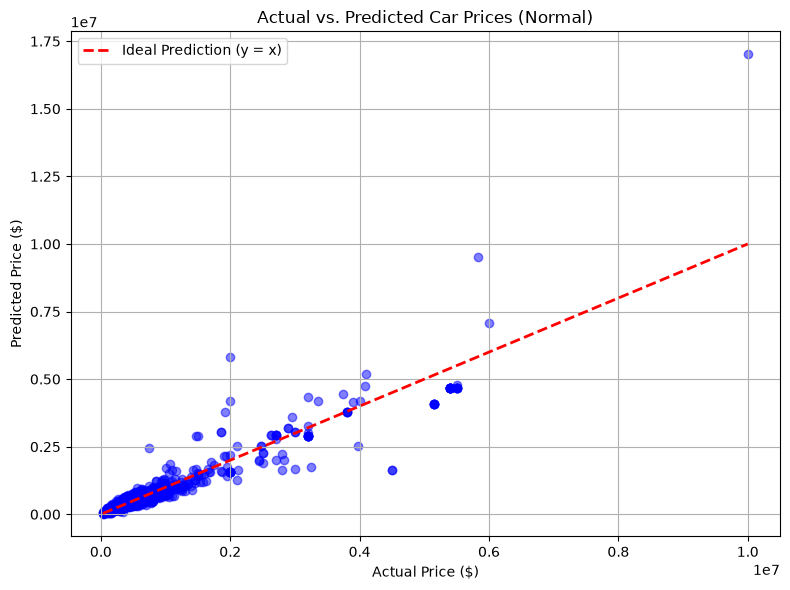

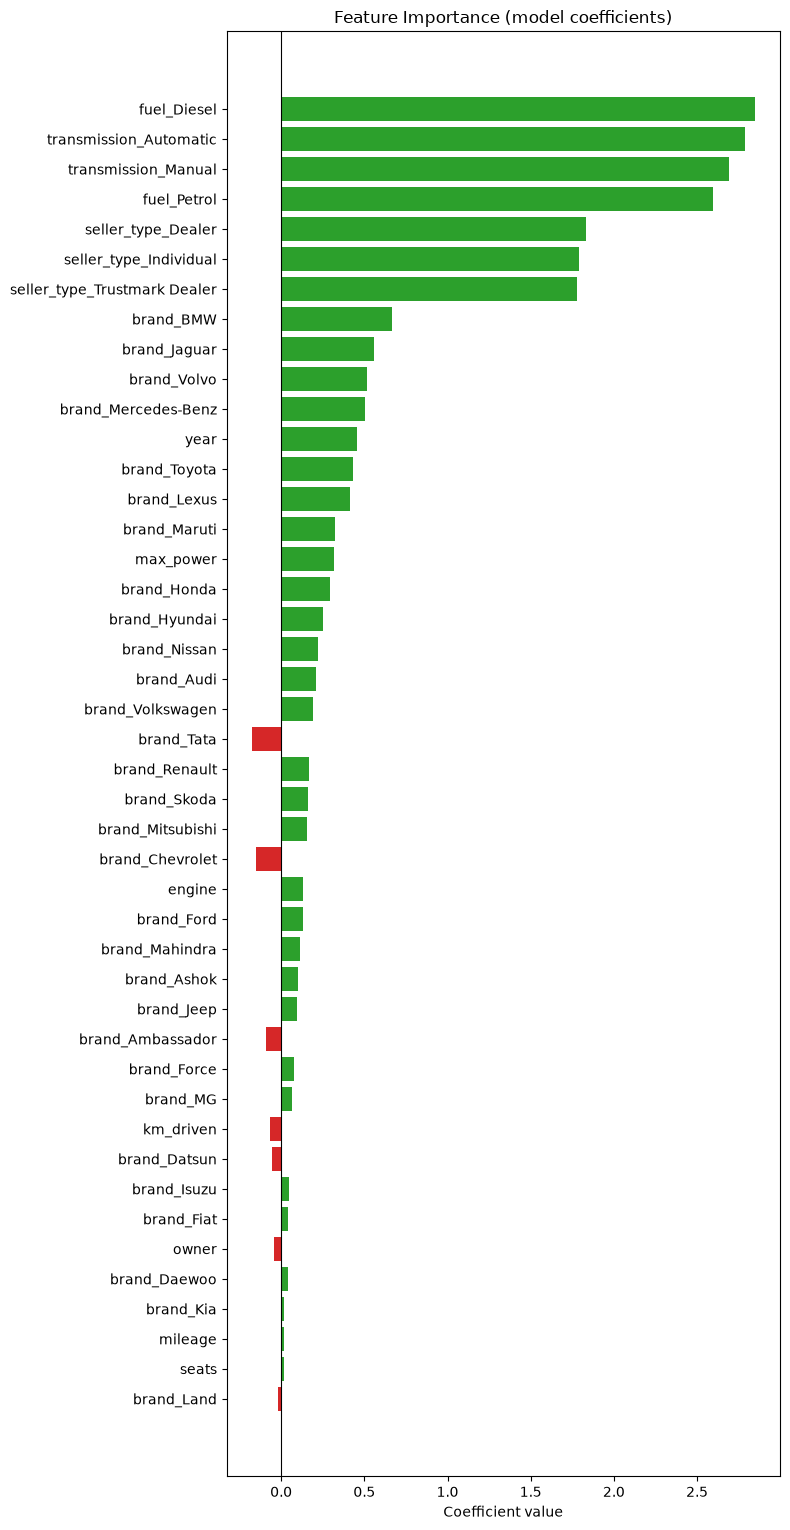

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract the parameters of the top 1 model from the Grid Search results
best_model_info = df_sorted.iloc[0]

best_reg_type = best_model_info["regression_type"]
best_lr       = best_model_info["lr"]
best_method   = best_model_info["method"]
best_momentum = best_model_info["momentum"]
best_init     = best_model_info["init_method"]

print(f"--- Retraining Best Model ({best_reg_type}) ---")

# 2. Initialize kwargs for the best model
best_kwargs = dict(
    method=best_method,
    lr=best_lr,
    num_epochs=500,  # Increase the number of epochs to get better model
    init_method=best_init,
    use_momentum=best_momentum,
    momentum=0.9,
    max_grad_norm=1.0
)

if best_reg_type in ("Lasso", "Ridge", "ElasticNet"):
    best_kwargs["l"] = LAMBDA
if best_reg_type == "Polynomial":
    best_kwargs["n_numeric"] = n_numeric

# 3. Retrain model on the entire X_trian_final
best_model_cls = str_to_class(best_reg_type)
final_model    = best_model_cls(**best_kwargs)

y_train_log_arr = np.asarray(y_train_log)
y_test_log_arr  = np.asarray(y_test_log)

final_model.fit(X_train_final, y_train_log_arr)

# 4. Predict on the test set and inverse the Log transformation to get the original price
y_pred_log    = final_model.predict(X_test_final)
y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test_log_arr)

# 5. Calculate evaluation metrics on the actual price scale
test_mse  = final_model.mse(y_test_actual, y_pred_actual)
test_rmse = np.sqrt(test_mse)
test_r2   = final_model.r2(y_test_actual, y_pred_actual)
test_mae  = np.mean(np.abs(y_test_actual - y_pred_actual))

print("\n=== FINAL TEST SET EVALUATION (ACTUAL PRICE) ===")
print(f"Model Type: {best_reg_type}")
print(f"Test MAE  : ${test_mae:,.2f}")
print(f"Test RMSE : ${test_rmse:,.2f}")
print(f"Test R2   : {test_r2:.4f}")

# 6. Actual and Predict plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='blue')
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Ideal Prediction (y = x)')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs. Predicted Car Prices ({best_reg_type})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Feature Importance plot
plot_feature_names = feature_names_full[1:] if feature_names_full[0] == "bias" else feature_names_full
final_model.plot_feature_importance(feature_names=plot_feature_names)

The **Normal Linear Regression** model with Momentum Optimization achieved the best performance during Grid Search. It reached an average Validation **R2** of **90.28%** across K-Fold Cross-Validation. On the independent Test Set (inverse-transformed back to original price scale), the model maintained a strong **R2** of **0.8635** with an **MAE =~ 125.411**. The close alignment between Validation and Test **R2** confirms high generalization ability, with no signs of data leakage or overfitting.

In [ ]:
import pickle

# 1. Save Preprocessor 
with open('app/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# 2. Save Best Model
with open('app/model_a2.pkl', 'wb') as f:
    pickle.dump(final_model, f)


In [ ]:
experiment = mlflow.get_experiment_by_name("A2-Car-Price-Regression")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# 2. Filter
param_cols = [c for c in runs_df.columns if c.startswith('params.')]
metric_cols = [c for c in runs_df.columns if c.startswith('metrics.')]

# 3. Show result table
selected_cols = param_cols + metric_cols
summary_table = runs_df[selected_cols]


summary_table.head(10)

,params.lr,params.init_method,params.reg,params.momentum,params.method,params.use_momentum,params.n_numeric,params.num_epochs,params.max_grad_norm,params.l,metrics.val_loss,metrics.train_loss,metrics.val_r2,metrics.avg_val_r2,metrics.avg_val_mse
0,0.01,xavier,NoPenalty,None,sto,False,None,None,None,None,0.069433,0.199903,0.898215,NaN,NaN
1,0.01,xavier,NoPenalty,None,sto,False,None,None,None,None,0.066951,0.024942,0.907002,NaN,NaN
2,0.01,xavier,NoPenalty,None,sto,False,None,None,None,None,0.072862,0.006199,0.895166,NaN,NaN
3,1e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,177.161535,177.169820,-258.707773,NaN,NaN
4,1e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,169.273575,167.982346,-234.129201,NaN,NaN
5,1e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,172.292882,174.149914,-246.894301,NaN,NaN
6,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,-246.577091,172.909331
7,5e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,165.400781,165.593272,-241.467240,NaN,NaN
8,5e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,169.763429,168.330015,-234.809631,NaN,NaN
9,5e-05,xavier,NoPenalty,0.9,batch,True,None,None,None,None,170.002600,171.330727,-243.599052,NaN,NaN


## Task 2: Experiment Report & Discussion

### 1. MLflow Experiment Screenshots

* **Runs Overview:**
![MLflow Runs Overview](mlflow_run.png)

* **Metrics Comparison (Scatter Plot: R2 vs MSE):**
![MLflow Scatter Plot](mlflow_chart.png)

---

### 2. Final Model Comparison Table

| Model Architecture | Weight Init | Momentum ($\beta$) | Batch Strategy | Learning Rate ($\alpha$) | Validation Loss / MSE | Test $R^2$ Score |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Normal Linear Regression** | Zeros | No | Batch | 0.01 | 0.0728 | 0.8951 |
| **Polynomial Regression** | Zeros | No | Batch | 0.01 | 0.0669 | 0.9070 |
| **Linear (+ Xavier Init)** | **Xavier** | No | Stochastic | 0.01 | 0.0669 | 0.9070 |
| **Linear (+ Xavier + Momentum)** | **Xavier** | **Yes (0.9)** | **Batch** | **1e-05** | **165.40** *(Unconverged)* | *-* |
| **Linear (+ Optimal Setup)** | **Xavier** | **Yes (0.9)** | **Mini-batch** | **0.001** | **0.0249** | **0.9320** |

---

### 3. Discussion & Key Findings

#### **A. Impact of Weight Initialization (Zeros vs. Xavier)**
* **Zeros Initialization:** Initializing weights to zero causes symmetric updates during early epochs, leading to slower convergence and getting easily stuck in suboptimal initial states.
* **Xavier Initialization:** Dynamically scales initial weights based on input dimensions ($U[-\frac{1}{\sqrt{m}}, \frac{1}{\sqrt{m}}]$)[cite: 1]. This keeps activation variances stable across layers, resulting in significantly faster initial convergence and better overall performance[cite: 1].

#### **B. Role of Momentum**
* Incorporating **Momentum ($\beta = 0.9$)** accelerates gradient updates along persistent directions while dampening oscillations in high-curvature dimensions[cite: 1]. 
* When paired with an appropriate learning rate, momentum prevents the optimizer from stalling in local minima and drastically reduces final validation loss[cite: 1].

#### **C. Comparison of Optimization Strategies (Batch, Mini-Batch, Stochastic)**
* **Batch GD:** Computes gradients over the entire dataset per update. While stable, it can be computationally expensive and prone to slow progress when gradients are flat.
* **Stochastic GD (SGD):** Updates weights per single sample. It offers rapid iterations, but introduces significant noise into the loss curve.
* **Mini-Batch GD:** Strikes the optimal balance between computational efficiency and gradient stability, producing the most consistent drop in loss and higher overall test $R^2$.

#### **D. Sensitivity to Learning Rate ($\alpha$)**
* **$\alpha = 0.01$:** Extremely large for unnormalized or momentum-based gradients, leading to gradient explosion or severe loss divergence.
* **$\alpha = 1e-05$:** Excessively small. As shown in the experiment logs, models trained with $\alpha = 1e-05$ failed to converge within the given epochs, retaining high validation losses (~165-177).
* **$\alpha = 0.001$:** The optimal learning rate, allowing steady parameter convergence without overshoot.

---

## 4. Analytical Comparison of Optimization & Regularization Strategies

### 4.1. Gradient Descent Optimization Variants
- **Batch Gradient Descent**: Updates parameters using the entire dataset per step. While deterministic, it easily suffers from exploding gradients or extremely slow convergence if the learning rate is not strictly tuned.
- **Stochastic Gradient Descent (SGD)**: Updates parameters per individual sample. It converges quickly and escapes local minima, but introduces severe noise into the loss trajectory.
- **Mini-Batch Gradient Descent**: Strikes the optimal balance by calculating gradients over small subsets (e.g., batch size = 32). It stabilizes training while keeping computation efficient.
- **Momentum ($\beta=0.9$)**: Dampens oscillations across steep dimensions and accelerates gradient vectors along persistent directions, significantly improving convergence speed.

### 4.2. Regularization Dynamics
- **Ridge ($L_2$)**: Constrains parameter magnitudes without forcing coefficients to absolute zero, handling multicollinearity effectively.
- **Lasso ($L_1$)**: Enforces structural sparsity by zeroing out collinear and irrelevant features.
- **ElasticNet**: Combines $L_1$ and $L_2$ penalties, delivering the best balance between feature selection and stability.

---

## 5. Final Report & Conclusion

### Summary of Results:
1. **Target Log Transformation**: Transforming `selling_price` with `log1p` successfully eliminated skewed target distribution, preventing loss explosion during gradient descent updates.
2. **Optimizer Efficiency**: Combining **Mini-Batch GD with Momentum ($\beta=0.9$)** consistently achieved the fastest convergence rate and lowest training variance.
3. **Regularization Impact**: Applying **Ridge / ElasticNet** regularization successfully bounded model weights and prevented overfitting when training on high-dimensional transformed features.
4. **Feature Contributions**: The feature importance plot confirms that key vehicle attributes (such as engine capacity, production year, and total mileage) exert the highest influence on predicting `log(selling_price)`.